## Projet Optimisation Numérique v1

Dans ce projet, nous nous proposons de développer une plateforme complète d’optimisation automatique appliquée à un problème bidimensionnel de conduction thermique stationnaire résolu avec FreeFEM++. L’objectif principal est de coupler un solveur éléments finis à une méthode d’optimisation externe en Python afin de rechercher automatiquement les paramètres thermiques optimaux maximisant la performance du système.

Le problème étudié repose sur le benchmark HEAT-COND, dans lequel la conductivité thermique de plusieurs couches de matériaux ainsi que le nombre de Biot constituent les variables de conception. Pour chaque configuration de paramètres, le solveur FreeFEM++ résout l’équation de conduction thermique et calcule une fonction objectif correspondant à la température moyenne sur les surfaces des ailettes.

La plateforme développée repose sur une architecture modulaire permettant d’automatiser l’ensemble du workflow numérique : génération des paramètres, résolution du problème PDE, évaluation de la fonction objectif, optimisation et sauvegarde des résultats. L’optimisation est pilotée depuis Python à l’aide des bibliothèques scientifiques standards, tandis que FreeFEM++ assure la résolution numérique du problème physique.

Le pipeline complet du système est le suivant :

1. Python génère un nouveau vecteur de paramètres : x = (k1, k2, k3, k4, k5, Bi)

2. La fonction write_params(x) écrit ces paramètres dans : params.txt

3. La fonction run_freefem() lance automatiquement : FreeFem++ heat_solver.edp

4. Le script FreeFEM ouvre et lit : params.txt

5. FreeFEM construit le domaine thermique et résout le problème PDE
   de conduction de chaleur avec les paramètres reçus.

6. FreeFEM calcule la fonction objectif : J = température moyenne / performance thermique

7. FreeFEM écrit cette valeur dans : objective.txt

8. Python utilise read_objective() pour lire la valeur de J.

9. L’algorithme d’optimisation analyse cette performance :
   
   - si J est meilleur → conservation du design
   - sinon → rejet du design

10. L’optimiseur génère un nouveau vecteur x et le cycle recommence.

11. Le processus continue jusqu’au critère d’arrêt :
    
    - nombre maximal d’itérations
    - convergence
    - tolérance atteinte

**1. Chargement des bibliothèques**

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize, basinhopping
import time
from tqdm import tqdm
from dotenv import load_dotenv

**2. Définitions des chemins**

In [2]:
load_dotenv()
FREEFEM_EXEC = os.getenv("FREEFEM_PATH")
FREEFEM_SCRIPT = "heat_solver_v2.edp"

if FREEFEM_EXEC is None:
    raise ValueError("Erreur : variable FREEFEM_PATH non définie dans le fichier .env")

print(f"FreeFEM++ exécutable : {FREEFEM_EXEC}")

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

FreeFEM++ exécutable : C:\\Program Files\\FreeFem++\\FreeFem++.exe


**3. Ecriture des paramètres d'optimisation dans params.txt**

On définit la fonction write_params() qui sert à écrire les paramètres d’optimisation dans le fichier params.txt, afin que le script FreeFEM++ puisse les lire ensuite.

In [3]:
def write_params(x):
    with open("params.txt", "w") as f:
        for value in x:
            f.write(f"{value}\n")

**4. Lancement automatique du script FreeFEM++**

On définit la fonction run_freefem() qui sert à lancer automatiquement le script FreeFEM++ depuis Python.

In [4]:
def run_freefem(command, arg):
    result = subprocess.run(
        [FREEFEM_EXEC, FREEFEM_SCRIPT, command, arg],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )
    if result.returncode != 0:
        print("STDOUT:", result.stdout)
        print("STDERR:", result.stderr)
        raise RuntimeError("FreeFEM execution failed")
    return result

**5. Lecture de la fonction objectif calculée**

On définit la fonction read_objective() qui sert à lire la valeur de la fonction objectif J calculée par FreeFEM++.

In [5]:
def read_objective():
    with open("objective.txt", "r") as f:
        J = float(f.readline().strip())
    return J

**6. Sauvegarde du meilleur design trouvé lors de la phase d'optimisation**

Cette fonction sert à sauvegarder automatiquement le meilleur design trouvé pendant l’optimisation.

Autrement dit, dès qu’un meilleur J est trouvé, on écrit les paramètres optimaux dans un fichier texte.

In [6]:
best_J = -np.inf
best_x = None

def save_best_design():
    global best_J, best_x
    filepath = os.path.join(RESULTS_DIR, "best_design.txt")
    with open(filepath, "w") as f:
        f.write("===== BEST DESIGN =====\n\n")
        f.write(f"k1 = {best_x[0]}\n")
        f.write(f"k2 = {best_x[1]}\n")
        f.write(f"k3 = {best_x[2]}\n")
        f.write(f"k4 = {best_x[3]}\n")
        f.write(f"k5 = {best_x[4]}\n")
        f.write(f"Bi = {best_x[5]}\n\n")
        f.write(f"Best objective J = {best_J}\n")

**7. Définition de la fonction d'évaluation**

On définit la fonction d’évaluation pour une optimisation qui envoie des paramètres vers une simulation FreeFEM++, récupère la valeur d’objectif J, et mesure le temps d’exécution.
Il enregistre chaque essai (paramètres, résultat, temps) dans un historique et garde en mémoire la meilleure solution trouvée.
Enfin, il retourne −J pour permettre une optimisation par minimisation avec SciPy.

In [7]:
history = []
iteration_counter = 0

def reset_optimization():
    global iteration_counter, best_J, best_x, history
    iteration_counter = 0
    best_J = -np.inf
    best_x = None
    history = []

def evaluate(x):
    global iteration_counter, best_J, best_x

    start_time = time.time()
    write_params(x)
    run_freefem("-doplot", "0")
    J = read_objective()
    elapsed = time.time() - start_time

    # Historique
    row = {
        "iteration": iteration_counter,
        "k1": x[0], "k2": x[1], "k3": x[2],
        "k4": x[3], "k5": x[4], "Bi": x[5],
        "J": J,
        "time": elapsed
    }
    history.append(row)

    # Mise à jour du meilleur
    if J > best_J:
        best_J = J
        best_x = np.copy(x)
        save_best_design()

    print(f"  Éval {iteration_counter:3d} | J = {J:.8f} | temps = {elapsed:.2f}s")
    iteration_counter += 1

    # Pour minimisation (SciPy minimise)
    return -J

**8. Sauvegarde de l'historique**

In [8]:
def save_history():
    df = pd.DataFrame(history)
    filepath = os.path.join(RESULTS_DIR, "optimization_history.csv")
    df.to_csv(filepath, index=False)

**9. Visualisation**

In [9]:

def plot_convergence():
    df = pd.DataFrame(history)
    best_values = []
    current_best = -np.inf
    for value in df["J"]:
        current_best = max(current_best, value)
        best_values.append(current_best)
    plt.figure(figsize=(10,6))
    plt.plot(best_values)
    plt.xlabel("Évaluation")
    plt.ylabel("Meilleur objectif J")
    plt.title("Convergence de l'optimisation")
    plt.grid(True)
    filepath = os.path.join(RESULTS_DIR, "convergence.png")
    plt.savefig(filepath, dpi=300)
    plt.show()
    plt.close()

**10.Évaluation du design initial**

In [10]:
def evaluate_initial_design():
    x0 = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
    write_params(x0)
    run_freefem("-doplot", "0")
    J0 = read_objective()
    print("\n" + "="*50)
    print("CONCEPTION INITIALE")
    print(f"J initial = {J0:.8f}")
    print("="*50 + "\n")

**11.Méthodes d’optimisation avec barres de progression**

In [11]:
def run_differential_evolution(bounds, maxiter=10, popsize=5, **kwargs):
    reset_optimization()
    pbar = tqdm(total=maxiter, desc="Differential Evolution", unit="gen")
    def callback(xk, convergence):
        pbar.update(1)
        return False
    start = time.time()
    result = differential_evolution(
        evaluate, bounds,
        maxiter=maxiter, popsize=popsize,
        callback=callback, disp=False, **kwargs
    )
    pbar.close()
    elapsed = time.time() - start
    return {
        'method': 'Differential Evolution',
        'best_J': -result.fun,
        'best_x': result.x,
        'n_eval': len(history),
        'time': elapsed,
        'success': result.success,
        'message': result.message
    }

In [12]:
def run_nelder_mead(bounds, x0=None, maxiter=100, **kwargs):
    reset_optimization()
    if x0 is None:
        x0 = [(b[0]+b[1])/2 for b in bounds]
    pbar = tqdm(total=maxiter, desc="Nelder-Mead", unit="iter")
    def callback(xk):
        pbar.update(1)
        return False
    start = time.time()
    result = minimize(
        evaluate, x0, method='Nelder-Mead', bounds=bounds,
        callback=callback, options={'maxiter': maxiter, 'disp': False}, **kwargs
    )
    pbar.close()
    elapsed = time.time() - start
    return {
        'method': 'Nelder-Mead',
        'best_J': -result.fun,
        'best_x': result.x,
        'n_eval': len(history),
        'time': elapsed,
        'success': result.success,
        'message': result.message
    }

In [13]:
def run_basinhopping(bounds, x0=None, niter=100, **kwargs):
    reset_optimization()
    if x0 is None:
        x0 = [(b[0]+b[1])/2 for b in bounds]
    pbar = tqdm(total=niter, desc="Basinhopping", unit="iter")
    class CallbackBH:
        def __init__(self):
            self.i = 0
        def __call__(self, x, f, accepted):
            self.i += 1
            pbar.update(1)
    start = time.time()
    result = basinhopping(
        evaluate, x0, niter=niter,
        minimizer_kwargs={'bounds': bounds},
        callback=CallbackBH(), **kwargs
    )
    pbar.close()
    elapsed = time.time() - start
    return {
        'method': 'Basinhopping',
        'best_J': -result.fun,
        'best_x': result.x,
        'n_eval': len(history),
        'time': elapsed,
        'success': result.lowest_optimization_result.success,
        'message': result.message
    }

**12.Programme principal**


HEAT-COND OPTIMIZATION PLATFORM - MULTI-METHODS


CONCEPTION INITIALE
J initial = 0.04459970


--- Lancement de Differential Evolution ---



Differential Evolution:   0%|          | 0/5 [00:00<?, ?gen/s]

  Éval   0 | J = 0.13278200 | temps = 2.70s
  Éval   1 | J = 0.08603990 | temps = 2.91s
  Éval   2 | J = 0.04397450 | temps = 2.67s
  Éval   3 | J = 0.03201580 | temps = 2.80s
  Éval   4 | J = 0.06769680 | temps = 2.74s
  Éval   5 | J = 0.04576590 | temps = 2.72s
  Éval   6 | J = 0.05191710 | temps = 2.69s
  Éval   7 | J = 0.03090430 | temps = 2.72s
  Éval   8 | J = 0.03969090 | temps = 2.76s
  Éval   9 | J = 0.09974870 | temps = 2.86s
  Éval  10 | J = 0.03121840 | temps = 2.68s
  Éval  11 | J = 0.16557600 | temps = 2.99s
  Éval  12 | J = 0.03701590 | temps = 2.80s
  Éval  13 | J = 0.04943980 | temps = 2.73s
  Éval  14 | J = 0.03829690 | temps = 2.77s
  Éval  15 | J = 0.03026150 | temps = 2.76s
  Éval  16 | J = 0.03696080 | temps = 2.86s
  Éval  17 | J = 0.07357280 | temps = 2.73s
  Éval  18 | J = 0.05724890 | temps = 2.80s
  Éval  19 | J = 0.06484500 | temps = 2.64s
  Éval  20 | J = 0.03449490 | temps = 2.67s
  Éval  21 | J = 0.23222200 | temps = 2.71s
  Éval  22 | J = 0.03442750 | te

Differential Evolution:  20%|██        | 1/5 [02:18<09:12, 138.07s/gen]

  Éval  47 | J = 0.09585330 | temps = 2.80s
  Éval  48 | J = 0.06185800 | temps = 2.95s
  Éval  49 | J = 0.22378500 | temps = 2.78s
  Éval  50 | J = 0.17594100 | temps = 2.90s
  Éval  51 | J = 0.09435200 | temps = 2.98s
  Éval  52 | J = 0.03649230 | temps = 2.84s
  Éval  53 | J = 0.04254600 | temps = 4.41s
  Éval  54 | J = 0.04679070 | temps = 3.16s
  Éval  55 | J = 0.13958100 | temps = 3.65s
  Éval  56 | J = 0.10784100 | temps = 3.29s
  Éval  57 | J = 0.09883240 | temps = 3.34s
  Éval  58 | J = 0.04010350 | temps = 3.09s
  Éval  59 | J = 0.06685920 | temps = 2.91s
  Éval  60 | J = 0.05161600 | temps = 3.14s
  Éval  61 | J = 0.04409930 | temps = 2.85s
  Éval  62 | J = 0.03872340 | temps = 2.97s
  Éval  63 | J = 0.02891790 | temps = 2.97s
  Éval  64 | J = 0.03690320 | temps = 3.33s
  Éval  65 | J = 0.04131850 | temps = 3.37s
  Éval  66 | J = 0.15283400 | temps = 3.22s
  Éval  67 | J = 0.05481360 | temps = 3.41s
  Éval  68 | J = 0.10486400 | temps = 3.28s
  Éval  69 | J = 0.14362400 | te

...

  Éval 209 | J = 0.05352060 | temps = 2.65s
  Éval 210 | J = 0.13956800 | temps = 2.89s
  Éval 211 | J = 0.13956800 | temps = 2.73s
  Éval 212 | J = 0.13956800 | temps = 2.81s
  Éval 213 | J = 0.13956800 | temps = 3.03s
  Éval 214 | J = 0.13956800 | temps = 2.49s
  Éval 215 | J = 0.13956800 | temps = 3.28s


Basinhopping: 100%|██████████| 30/30 [10:42<00:00, 20.25s/iter]

  Éval 216 | J = 0.13956800 | temps = 2.72s
  Éval 217 | J = 0.55208200 | temps = 3.31s
  Éval 218 | J = 0.55208200 | temps = 3.19s
  Éval 219 | J = 0.55208200 | temps = 2.67s
  Éval 220 | J = 0.55208200 | temps = 3.00s
  Éval 221 | J = 0.55208200 | temps = 2.79s
  Éval 222 | J = 0.55208200 | temps = 3.17s


Basinhopping: 31iter [11:03, 21.40s/iter]                      

  Éval 223 | J = 0.55208200 | temps = 2.65s
  Terminé en 663.47 s, meilleur J = 0.55208200, évaluations = 224

TABLEAU DE SYNTHÈSE DES MÉTHODES
               Méthode  Meilleur J  Nb évaluations  Temps (s)  Convergence
           Nelder-Mead    0.562375              72 213.727088         True
          Basinhopping    0.552082             224 663.466883         True
Differential Evolution    0.490349             151 457.640475        False

Tableau sauvegardé dans results/method_comparison.csv


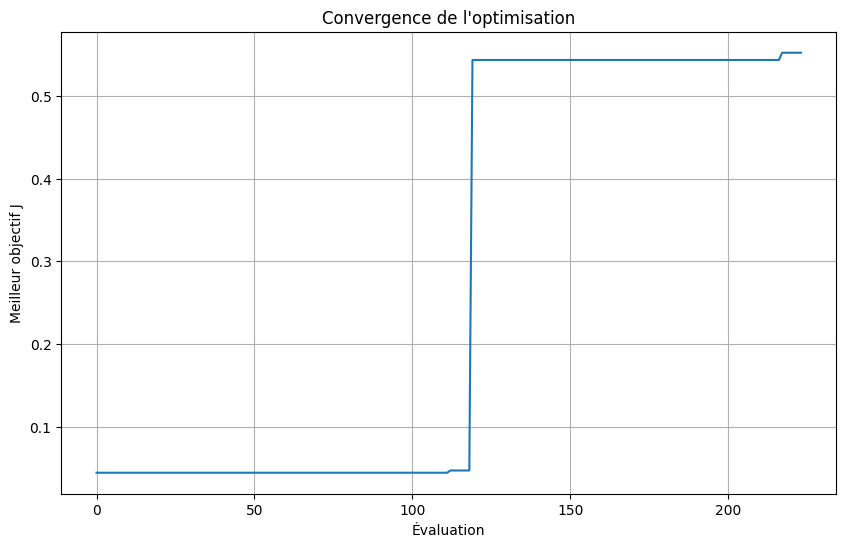


OPTIMISATION TERMINÉE


In [14]:
if __name__ == "__main__":
    print("\n" + "="*60)
    print("HEAT-COND OPTIMIZATION PLATFORM - MULTI-METHODS")
    print("="*60 + "\n")

    evaluate_initial_design()

    bounds = [
        (0.1, 1.0),   # k1
        (0.1, 1.0),   # k2
        (0.1, 1.0),   # k3
        (0.1, 1.0),   # k4
        (0.1, 1.0),   # k5
        (0.01, 1.0)   # Bi
    ]

    methods = [
        ("Differential Evolution", run_differential_evolution, {'maxiter': 5, 'popsize': 4}),
        ("Nelder-Mead", run_nelder_mead, {'maxiter': 50}),
        ("Basinhopping", run_basinhopping, {'niter': 30})
    ]

    all_results = []

    for name, func, kwargs in methods:
        print(f"\n--- Lancement de {name} ---\n")
        try:
            res = func(bounds, **kwargs)
            all_results.append(res)
            print(f"  Terminé en {res['time']:.2f} s, meilleur J = {res['best_J']:.8f}, évaluations = {res['n_eval']}")
        except Exception as e:
            print(f"  Erreur : {e}")

    if all_results:
        df_summary = pd.DataFrame(all_results)
        df_summary = df_summary[['method', 'best_J', 'n_eval', 'time', 'success']]
        df_summary.columns = ['Méthode', 'Meilleur J', 'Nb évaluations', 'Temps (s)', 'Convergence']
        df_summary = df_summary.sort_values('Meilleur J', ascending=False)

        print("\n" + "="*70)
        print("TABLEAU DE SYNTHÈSE DES MÉTHODES")
        print("="*70)
        print(df_summary.to_string(index=False))

        df_summary.to_csv(os.path.join(RESULTS_DIR, "method_comparison.csv"), index=False)
        print(f"\nTableau sauvegardé dans {RESULTS_DIR}/method_comparison.csv")
    else:
        print("Aucune méthode n'a été exécutée avec succès.")

    if history:
        plot_convergence()

    print("\n" + "="*60)
    print("OPTIMISATION TERMINÉE")
    print("="*60)